# Road Accident Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: UK road collisions in 2021 — 101,087 records from the DfT with severity, vehicles, casualties, timing, speed limit, and road/weather conditions. This notebook covers the data overview — shape, types, missing values, and univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (101087, 15)


,collision_index,date,day_of_week,time,collision_severity,number_of_vehicles,number_of_casualties,speed_limit,light_conditions,weather_conditions,road_surface_conditions,urban_or_rural_area,road_type,longitude,latitude
0,2021170H10581,07/07/2021,4,12:30,3,2,1,30,1,1,1,1,6,-1.215535,54.705385
1,2021170M10181,26/02/2021,6,19:30,2,1,1,30,4,1,1,1,6,-1.246477,54.565540
2,2021170M30721,20/05/2021,5,16:45,3,2,1,40,1,2,2,1,1,-1.212540,54.521556
3,2021170L50121,30/01/2021,7,18:08,2,1,1,30,4,1,1,2,6,-0.894618,54.555397
4,2021111130730,19/10/2021,3,19:44,3,2,2,30,4,2,2,1,6,-1.549932,54.529984


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('int64'): 10, dtype('O'): 3, dtype('float64'): 2}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101087 entries, 0 to 101086
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   collision_index          101087 non-null  object 
 1   date                     101087 non-null  object 
 2   day_of_week              101087 non-null  int64  
 3   time                     101087 non-null  object 
 4   collision_severity       101087 non-null  int64  
 5   number_of_vehicles       101087 non-null  int64  
 6   number_of_casualties     101087 non-null  int64  
 7   speed_limit              101087 non-null  int64  
 8   light_conditions         101087 non-null  int64  
 9   weather_conditions       101087 non-null  int64  
 10  road_surface_conditions  101087 non-null  int64  
 11  urban_or_rural_area      101087 non-null  int64  
 12  road_type                101087 non-null  int64  
 13  lo

## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 2
           missing   pct
longitude       17  0.02
latitude        17  0.02


## 3. Numeric distributions

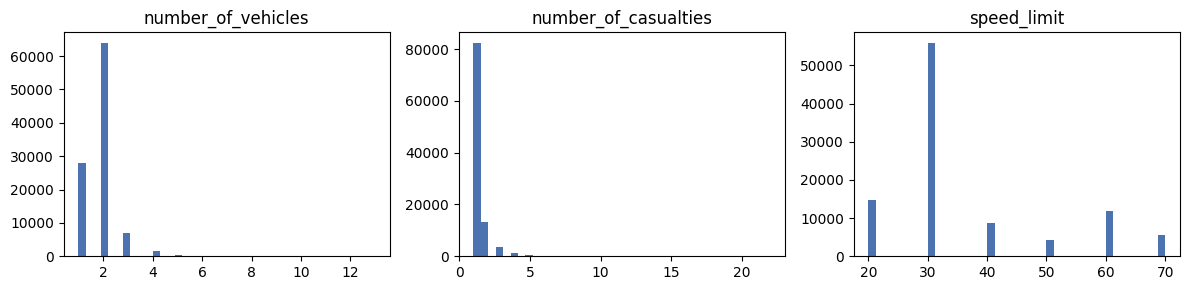

,number_of_vehicles,number_of_casualties,speed_limit
count,101087.00,101087.00,101087.00
mean,1.84,1.27,36.00
std,0.68,0.67,14.12
min,1.00,1.00,20.00
25%,1.00,1.00,30.00
50%,2.00,1.00,30.00
75%,2.00,1.00,40.00
max,13.00,22.00,70.00


In [4]:
num=['number_of_vehicles', 'number_of_casualties', 'speed_limit']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

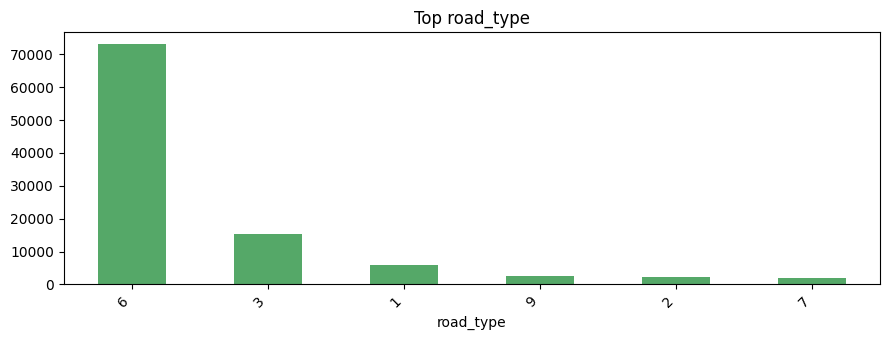

road_type
6    73054
3    15299
1     5947
9     2607
2     2300
7     1880


In [5]:
vc=utils.top_counts(df['road_type'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top road_type'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above frames the domain questions answered in notebook **02 — Analysis**, where the real insights and the headline numbers (reported in the README) come from.